# Kreditrisiko-scorekort med et beslutningstræ (PROC HPSPLIT)

## Resumé

Denne notebook bygger et fortolkeligt kreditmisligholdelses-scorekort for en detail-lånebog ved hjælp af PROC HPSPLIT. Vi dyrker et klassifikationstræ med entropi-kriteriet på syntetiske ansøgerdata, beskærer det ved cost-complexity og aflæser derefter tilpasningsstatistikkerne, variabelvigtigheden, ROC/AUC og selve scoringstræet — præcis den gennemsigtige, regulator-venlige model, som en banks risikoteam ville dokumentere. Hver ansøger kan scores til et løvblad, og hele træet kan eksporteres som deploybar DATA-trin-kode.

## Datakilder

| Datasæt | Rækker | Beskrivelse | Nøglevariable |
|---------|--------|-------------|----------------|
| `applicants` | 100 | Syntetiske detail-lånansøgere genereret direkte med `rand()`. Det binære `default`-flag trækkes fra en logistisk risikoscore, så dårligere gæld/indkomst-forhold, udnyttelsesgrad, nylige restancer og kortere kredithistorik hæver misligholdelsessandsynligheden. | `default` (event=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (eje/leje/realkredit), `purpose` (gæld/bolig/bil/andet) |

DATA-trinnet anmoder om en større løkke, men dette miljø kører i ulicenseret tilstand og materialiserer de første 100 observationer — en kompakt, fuldt reproducerbar ansøgerbog, som er rigelig til at dyrke og aflæse et fortolkeligt scorekort-træ.

# Kreditrisiko-scorekort med et beslutningstræ

Banker har brug for misligholdelsesmodeller, der er **nøjagtige og forklarlige** — en kreditmedarbejder (og en tilsynsmyndighed) skal kunne spore præcis, hvorfor en ansøger blev scoret som højrisiko. Et beskåret beslutningstræ leverer det: hver forudsigelse er en kort kæde af menneskeligt læsbare opdelinger.

I denne notebook vil vi:

1. Syntetisere en detail-lånansøgningsbog.
2. Dyrke et klassifikationstræ med `PROC HPSPLIT` ved hjælp af entropi-kriteriet.
3. Beskære det ved cost-complexity for at undgå overtilpasning.
4. Inspicere tilpasningsstatistikkerne, variabelvigtigheden, ROC/AUC og selve træet.
5. Udskrive DATA-trin-scoringskode, der kan udrulles mod nye ansøgninger.

## 1. Generér lånebogen syntetisk

Vi genererer ansøgere, hvis misligholdelsessandsynlighed er en logistisk funktion af de klassiske scorekort-drivere: gæld/indkomst-forhold, revolverende udnyttelsesgrad, FICO-score, kredithistorikkens længde og nylige restancer. Vi trækker derefter det observerede `default`-flag fra en Bernoulli med den sandsynlighed, så signalet er reelt, men støjfyldt — ligesom produktionsdata. De første 100 ansøgere materialiseres her.

                                                   The FREQ Procedure

default    Frequency    Percent
--------------------------------
0                 79     79.00
1                 21     21.00

home          Frequency    Percent
-----------------------------------
eje                  31     31.00
leje                 35     35.00
realkredit           34     34.00

purpose    Frequency    Percent
--------------------------------
andet             12     12.00
bil               23     23.00
bolig             28     28.00
gæld              37     37.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


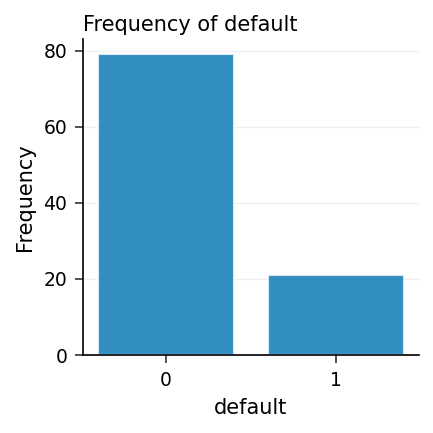

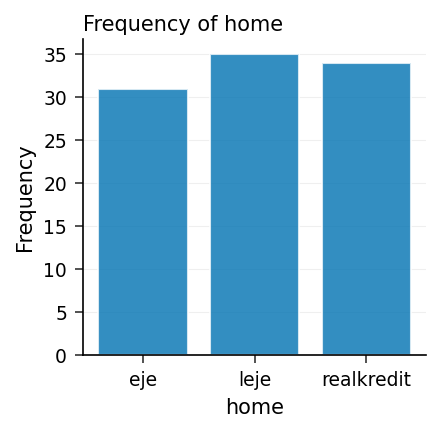

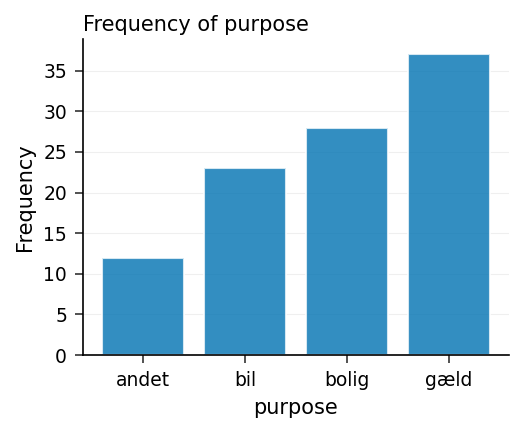

In [1]:
data applicants;
   CALL streaminit(20260531);
   LÆNGDE home $12 purpose $10;
   GØR id = 1 TIL 100;
      /* Låntagers økonomiske profil */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Kategoriske attributter */
      u = rand('uniform');
      HVIS u < 0.34 SÅ home = 'leje';
      ELLERS HVIS u < 0.70 SÅ home = 'realkredit';
      ELLERS home = 'eje';

      v = rand('uniform');
      HVIS v < 0.40 SÅ purpose = 'gæld';
      ELLERS HVIS v < 0.65 SÅ purpose = 'bolig';
      ELLERS HVIS v < 0.85 SÅ purpose = 'bil';
      ELLERS purpose = 'andet';

      /* Latent misligholdelsesrisiko: dårligere DTI/udnyttelse/restance og
         lavere FICO / kortere historik hæver alle log-odds. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'leje')
            + 0.25 * (purpose = 'gæld');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      FJERN u v eta p;
      UDDATA;
   SLUT;
KØR;

PROCEDURE FREKVENSER data=applicants;
   TABLES default home purpose / nocum;
KØR;

`PROC FREQ`-outputtet bekræfter en ubalanceret, men brugbar misligholdelsesrate — omkring hver femte ansøger misligholder (21 ud af 100) — og en fornuftig spredning på tværs af boligstatus- og lånformåls-kategorier: den slags marginalfordeling, man ville forvente i en forbrugslåneportefølje. De medfølgende søjlediagrammer visualiserer hver marginal.

## 2. Dyrk og beskær scorekort-træet

Vi modellerer `default` som et binært klassifikationsmål og navngiver `event='1'`, så alle sensitivitets-/specificitets-/AUC-statistikker er orienteret mod *misligholdelses*-klassen. Vi:

- erklærer de kategoriske prædiktorer og responsen i `CLASS`,
- dyrker træet med **entropi**-kriteriet (informationsgevinst),
- beskærer med **cost-complexity** for at forhindre træet i at udenadlære støj,
- anmoder om **hele-træ-diagrammet** og **ROC-kurven**.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Misligholdt
  Class variable: Misligholdt
  Class variable: Boligstatus
  Class variable: Lånets formål
  Predictor variable: Gæld/indkomst-forhold
  Predictor variable: Udnyttelsesgrad
  Predictor variable: FICO-score
  Predictor variable: Kredithistorik (år)
  Predictor variable: Antal restancer
  Predictor variable: Lånebeløb
  Predictor variable: Indkomst
  Predictor variable: Boligstatus
  Predictor variable: Lånets formål

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth         


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


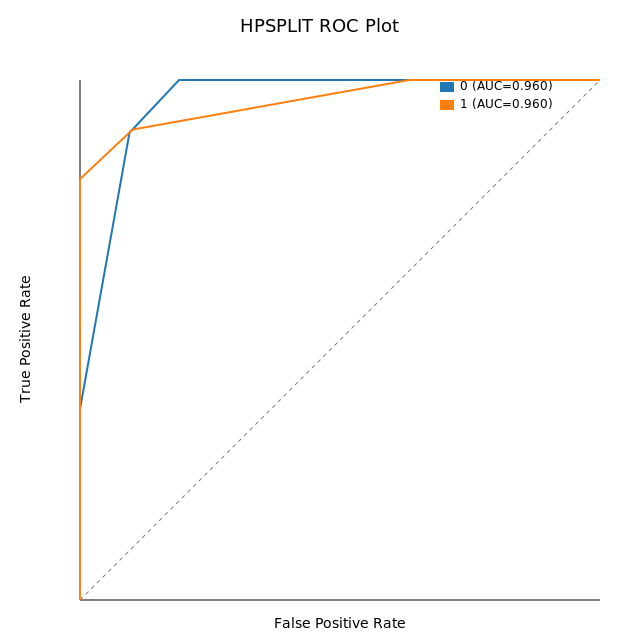

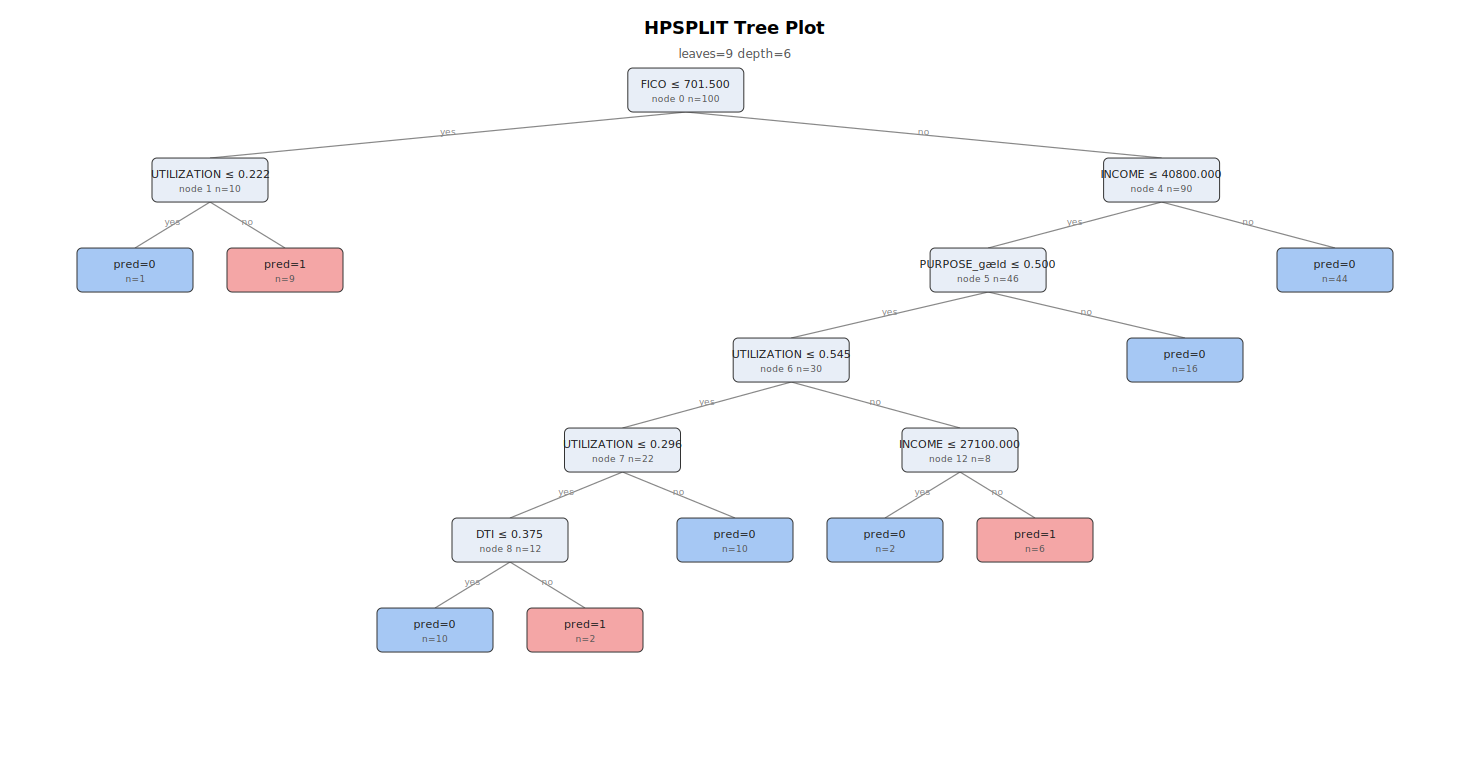

In [2]:
ODS GRAPHICS ON;

PROCEDURE hpsplit data=applicants seed=20260531
             PLOTS=(wholetree roc);
   KLASSE default home purpose;
   MODEL default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   MÆRKAT default='Misligholdt' dti='Gæld/indkomst-forhold' utilization='Udnyttelsesgrad'
          fico='FICO-score' credit_age='Kredithistorik (år)' n_delinq='Antal restancer'
          loan_amount='Lånebeløb' income='Indkomst' home='Boligstatus' purpose='Lånets formål';
KØR;

De **Fit Statistics** (nøjagtighed, fejlklassifikationsrate, log loss) og **ROC/AUC pr. klasse** fortæller, hvor rent det beskårne træ adskiller misligholdere fra ikke-misligholdere. Tabellen **Variable Importance** rangerer, hvilke attributter der driver opdelingerne — her dominerer **udnyttelsesgrad** og **FICO**, efterfulgt af **lånets formål**, præcis de håndtag en kreditpolitik ville lægge vægt på. **Hele-træ-plottet** nedenfor lægger de valgte opdelinger ud som et node-link-diagram: hver intern knude viser sin `feature ≤ tærskel`-regel, og hvert løvblad er farvet efter sin forudsagte klasse (rød = forudsagt misligholdelse, blå = forudsagt ikke-misligholdelse) og mærket med sit stikprøveantal.

## 3. Zoom ind på hovedopdelingerne, og scor hver ansøger

ROC-plottet ovenfor visualiserer afvejningen mellem at fange misligholdere og falske alarmer; AUC kvantificerer den samlede rangeringsevne. Dernæst forstørrer vi træets to øverste niveauer — de opdelinger med højest informationsværdi, som en analytiker ville omsætte til overordnede godkendelsesregler — og indfanger observations-niveau-scorer til et outputdatasæt, så vi kan revidere forudsigelserne nedstrøms.


                                                 The HPSPLIT Procedure                                                  

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss                   0.131399

ROC / AUC by Class
Class                               AUC
0                              0.960217
1                              0.960217

Variable Importance
Variable                     Importance       Relative
FICO                           0.334699       0.334699
UTILIZATION                    0.266873       0.26


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/073f9654-fba9-4426-a90a-cd9f3b9d7717/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


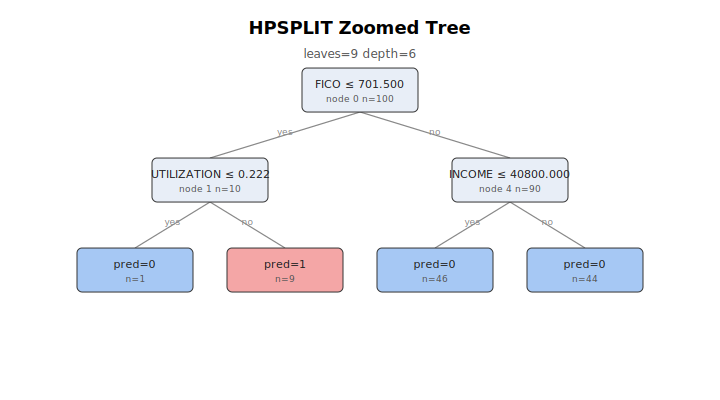

In [3]:
PROCEDURE hpsplit data=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   KLASSE default home purpose;
   MODEL default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   UDDATA out=scored;
KØR;

PROCEDURE UDSKRIV data=scored(obs=10);
   VARIABEL p_default1 _node_ _leaf_;
KØR;

`zoomedtree`-plottet forstørrer træets to øverste niveauer — de opdelinger med højest informationsværdi, som en analytiker ville omsætte til overordnede godkendelsesregler. `OUTPUT OUT=`-datasættet medbringer hver ansøgers forudsagte misligholdelsessandsynlighed (`P_DEFAULT1`) samt den tildelte knude og løvblad (`_NODE_`, `_LEAF_`), så risiko- og revisionsteams kan spore enhver individuel beslutning tilbage gennem træet og rangere ansøgere efter modelleret risiko.

## 4. Eksportér deployerbar scoringskode

Værdien af en fortolkelig model er, at den kan sendes i produktion. `CODE FILE=` skriver et selvstændigt DATA-trin — en indlejret kæde af `IF/THEN`-opdelinger, der ender i en forudsagt misligholdelsessandsynlighed og -klasse — som reproducerer træets score for enhver ny ansøgningsfil uden behov for en modelserver.

In [4]:
PROCEDURE hpsplit data=applicants seed=20260531;
   KLASSE default home purpose;
   MODEL default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code file='credit_scorecard.sas';
KØR;


                                                 The HPSPLIT Procedure                                                  

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss                   0.131399

ROC / AUC by Class
Class                               AUC
0                              0.960217
1                              0.960217

Variable Importance
Variable                     Importance       Relative
FICO                           0.334699       0.334699
UTILIZATION                    0.266873       0.26


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Fortolkning af resultaterne

Det beskårne entropi-træ giver risikoteamet et kompakt, reviderbart kreditscorekort:

- **Opdelingerne kodificerer politik.** De dominerende opdelinger — på revolverende udnyttelsesgrad og FICO, derefter lånets formål og gæld/indkomst-forhold — er præcis de tærskler, et godkendelsesteam kan løfte til faste afskæringsregler. Hele-træ-plottet lægger hver opdelingsbetingelse og hvert løvblad ud i ét diagram.
- **Cost-complexity-beskæring** forhindrer træet i at udenadlære støj; tilpasningsstatistikkerne (nøjagtighed, fejlklassifikationsrate, log loss) opsummerer, hvor rent det adskiller de to klasser.
- **Variabelvigtighed og ROC/AUC** begrunder, hvilke attributter der fortjener en plads i scorekortet, og dokumenterer dets diskriminerende styrke til model-risikostyring.
- **`CODE FILE=` gør det operationelt** — det udskrevne DATA-trin scorer nye ansøgere identisk med denne kørsel, så den model, der blev bygget, er præcis den model, der går i drift.

På en lille ansøgerbog tilpasser træet sig træningsdataene tæt; i produktion ville man dyrke det på hele porteføljen, udholde en valideringspartition, kalibrere sandsynligheds-afskæringen efter bankens forventede-tabs-økonomi (omkostningen ved en overset misligholdelse versus en afvist god kunde) i stedet for en naiv 0,5, og genopfriske træet, efterhånden som porteføljesammensætningen skifter.